<a href="https://colab.research.google.com/github/dhrupsarkar965/data-analysis-projects/blob/main/IPL_Data_Analysis_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
deliveries=pd.read_csv("/content/deliveries (1).csv")
matches=pd.read_csv("/content/matches.csv")

#Succes rate of team

In [ ]:
ipl_teams_matches=pd.concat([matches['team1'],matches['team2']])

In [ ]:
ipl_team_win=matches.groupby('winner')['winner'].count()

In [ ]:
succes_rate=(ipl_team_win/ipl_teams_matches.value_counts())*100

In [ ]:
succes_rate=succes_rate.sort_values(ascending=False)

In [ ]:
succes_rate1=succes_rate.reset_index()

In [ ]:
succes_rate1.columns=['Team','Success Rate']

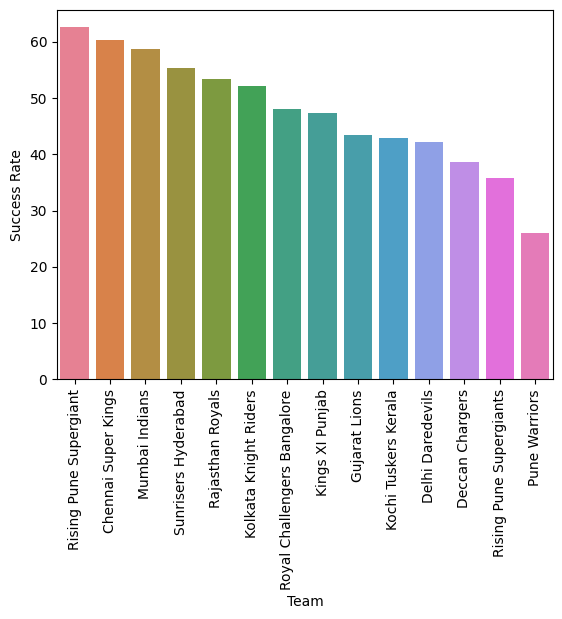

In [ ]:
sns.barplot(data=succes_rate1,x='Team',y='Success Rate',hue='Team')
plt.xticks(rotation=90)
plt.show()

**The above graph  demonstrates that Chennai Super Kings, Mumbai Indians, and Rising Pune Supergiant are the most historically dominant teams in the dataset, each maintaining a success rate near or above 60%. Conversely, Pune Warriors struggled the most, securing the lowest success rate at roughly 26%. The remaining majority of the teams exhibit a balanced level of competitiveness, maintaining overall win rates between 40% and 55%.**

#Most title win by teams

In [ ]:
title_teams=matches.groupby('season')[['season','winner']].tail(1)['winner'].value_counts()

In [ ]:
title_teams1=title_teams.reset_index()


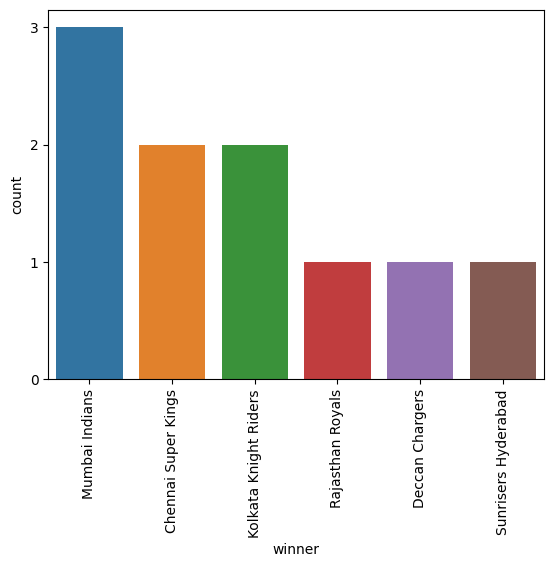

In [ ]:
sns.barplot(data=title_teams1,x='winner',y='count',hue='winner')
plt.xticks(rotation=90)
# Manually set ticks from 0 to 3
plt.yticks([0, 1, 2, 3])

plt.show()

**The above  graph show the distribution of tournament championships among winning franchises. One dominant team leads the league with 3 titles, followed by two teams tied with 2 titles each. The remaining three teams have each captured a single championship, demonstrating that while a few franchises historically dominate, title success is distributed across multiple teams.**

#Top 10 players with most runs

In [ ]:
deliveries.head(2)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN


In [ ]:
top_batsman=deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

In [ ]:
top_batsman1=top_batsman.reset_index()

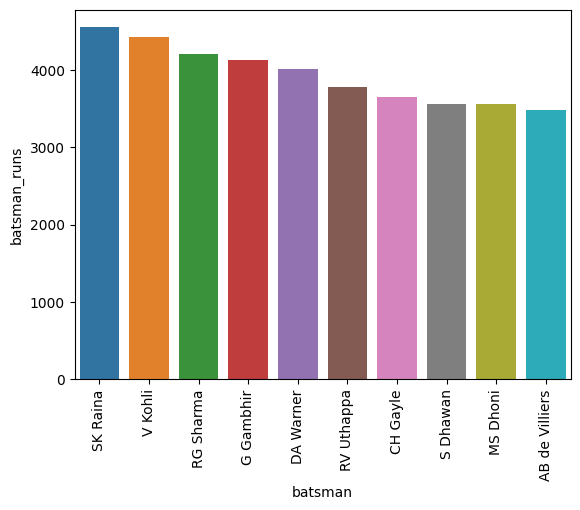

In [ ]:
sns.barplot(data=top_batsman1,x='batsman',y='batsman_runs',hue='batsman')
plt.xticks(rotation=90)
plt.show()


**The bar chart highlights the top 10 highest run-scorers in the tournament's history within this dataset. SK Raina holds the top position, with Virat Kohli trailing closely behind in second place. A significant finding is that the top five batsmen have successfully surpassed the 4,000-run mark. The narrow margin between all ten players demonstrates a highly consistent group of elite top-order and middle-order batsmen who have anchored their respective franchises over multiple seasons.**

#Top 10 Best performance in a match

In [ ]:
deliveries.head(1)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN


In [ ]:
best_performance=deliveries.groupby(['match_id','batsman'])['batsman_runs'].sum().sort_values(ascending=False).head(10)

In [ ]:
best_performance1=best_performance.reset_index().head(10)

In [ ]:
best_performance1

,match_id,batsman,batsman_runs
0,411,CH Gayle,175
1,60,BB McCullum,158
2,562,AB de Villiers,133
3,620,AB de Villiers,129
4,372,CH Gayle,128
5,206,M Vijay,127
6,36,DA Warner,126
7,516,V Sehwag,122
8,243,PC Valthaty,120
9,279,V Sehwag,119


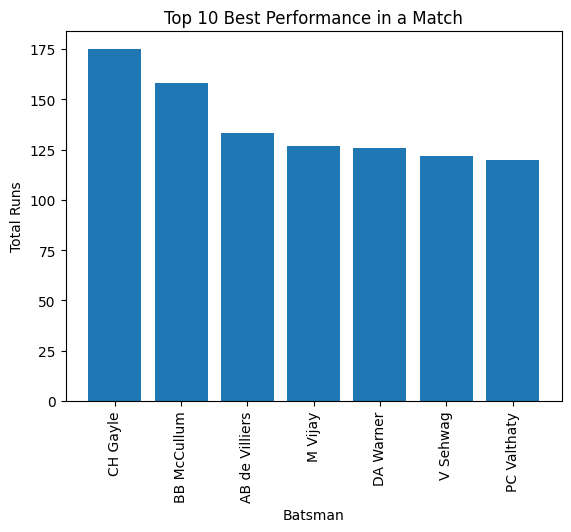

In [ ]:
plt.bar(best_performance1['batsman'],best_performance1['batsman_runs'])
plt.title("Top 10 Best Performance in a Match")
plt.xlabel("Batsman")
plt.ylabel("Total Runs")
plt.xticks(rotation=90)
plt.show()
#

**The bar chart highlights the top individual batting performances in a single match within the tournament's history. Chris Gayle dominates the chart with a record-shattering performance of 175 runs, followed by Brendon McCullum's iconic explosive innings near 158 runs. Beyond the top two outliers, the graph displays a highly competitive tier of elite performances, where five different batsmen achieved remarkable scores ranging tightly between 120 and 135 runs in a single innings.**

#Top 10 Stricke Rate Of a Player

In [ ]:
deliveries.head(1)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN


In [ ]:
top_stricke_rate=(deliveries.groupby(['match_id','batsman'])['batsman_runs'].sum().sort_values(ascending=False)/deliveries.groupby(['match_id','batsman'])['ball'].sum().sort_values(ascending=False))*100

In [ ]:
top_stricke_rate1=top_stricke_rate.sort_values(ascending=False).reset_index()

In [ ]:
top_stricke_rate1.rename(columns={0:'Strike Rate'},inplace=True)

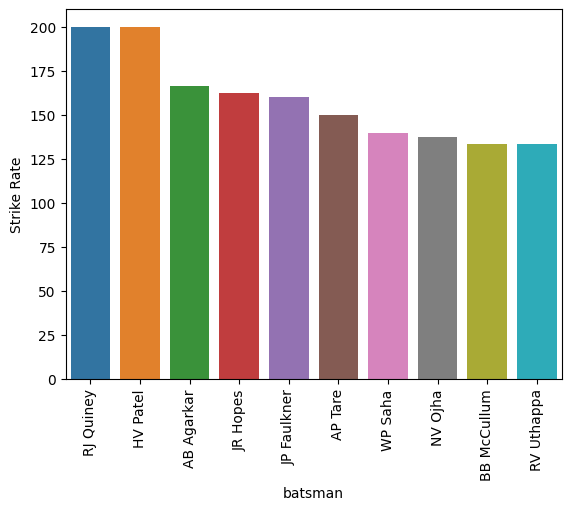

In [ ]:
sns.barplot(data=top_stricke_rate1.head(10),x='batsman',y='Strike Rate',hue='batsman')
plt.xticks(rotation=90)
plt.show()

***The bar chart depicts the highest individual batting strike rates recorded within the current scope of the dataset. RJ Quiney and HV Patel anchor the top positions with a strike rate of 200, followed by a competitive tier of players like AB Agarkar and JR Hopes scoring above 150. However, because this visualization tracks unaggregated single-match performances or small sample sizes rather than lifetime career stats, it elevates short-term cameos above long-term franchise mainstays.*

#Top 10 bowler with most wicket

In [ ]:
deliveries.head(2)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN


In [ ]:
top_bowler=deliveries.groupby('bowler')['dismissal_kind'].count().sort_values(ascending=False).head(10).reset_index()

In [ ]:
top_bowler.rename(columns={'dismissal_kind':'total wicket'},inplace=True)

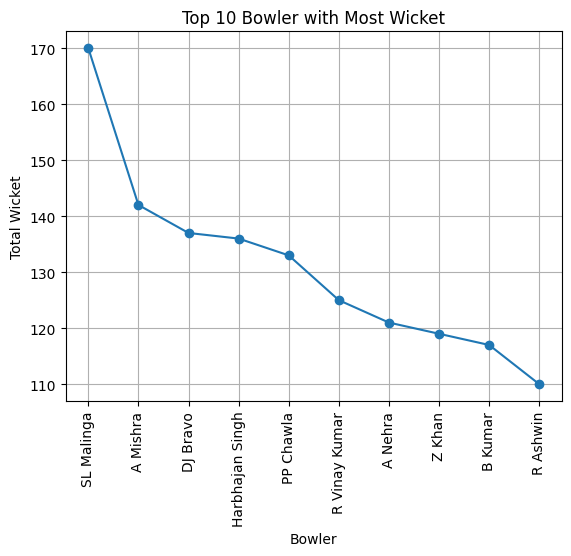

In [ ]:
plt.plot(top_bowler['bowler'],top_bowler['total wicket'],marker='o')
plt.title("Top 10 Bowler with Most Wicket")
plt.xlabel("Bowler")
plt.ylabel("Total Wicket")
plt.xticks(rotation=90)
plt.grid()
plt.show()

#top 10 best bowling performance


In [ ]:
best_bowling=deliveries.groupby(['match_id','bowler'])['dismissal_kind'].count().sort_values(ascending=False).head(10).reset_index()


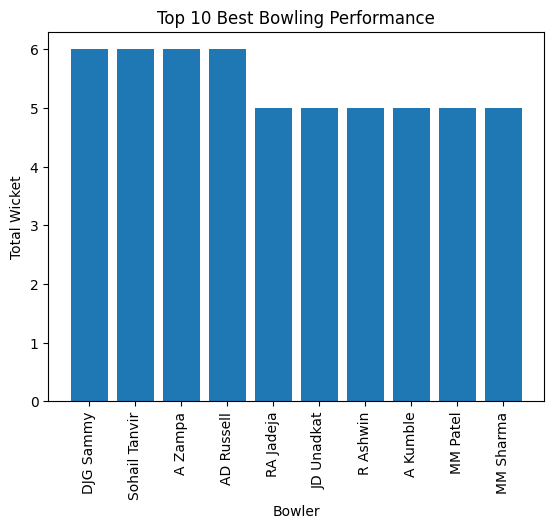

In [ ]:
plt.bar(best_bowling['bowler'],best_bowling['dismissal_kind'])
plt.title("Top 10 Best Bowling Performance")
plt.xlabel("Bowler")
plt.ylabel("Total Wicket")
plt.xticks(rotation=90)

plt.show()


#Top 10 cities by number of matches

In [ ]:
top_cities=matches['city'].value_counts().head(10).reset_index()

In [ ]:
top_cities.rename(columns={'count':'matches played'},inplace=True)

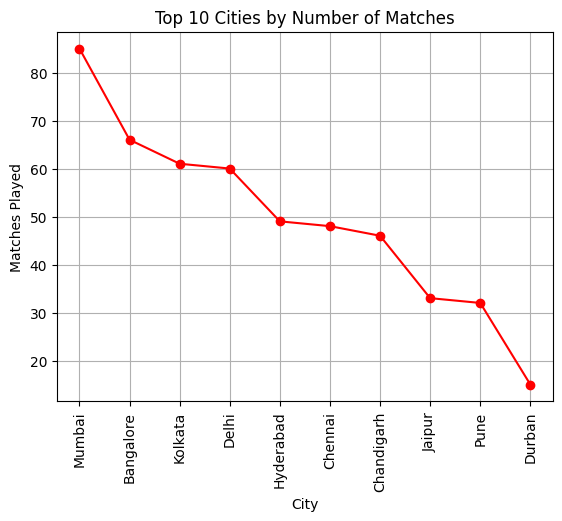

In [ ]:
plt.plot(top_cities['city'],top_cities['matches played'],marker='o',color='red')
plt.title("Top 10 Cities by Number of Matches")
plt.xlabel("City")
plt.ylabel("Matches Played")
plt.xticks(rotation=90)
plt.grid()
plt.show()

In [ ]:
deliveries.head(1)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN


#top 10 dismissal kind

In [ ]:

dismissal=deliveries['dismissal_kind'].value_counts().head(10).reset_index()


In [ ]:
dismissal.rename(columns={'count':'total dismissal'},inplace=True)

In [ ]:
dismissal

,dismissal_kind,total dismissal
0,caught,4373
1,bowled,1382
2,run out,755
3,lbw,455
4,stumped,243
5,caught and bowled,211
6,retired hurt,9
7,hit wicket,9
8,obstructing the field,1


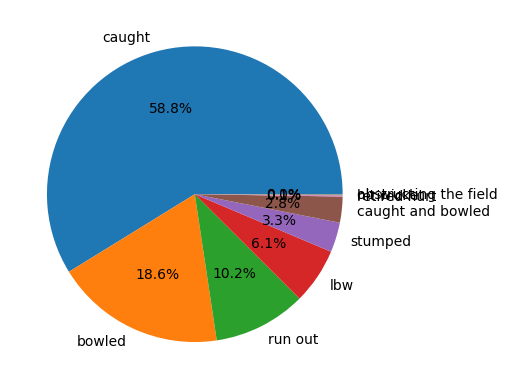

In [ ]:
plt.scatter(dismissal[''],labels=dismissal['dismissal_kind'],autopct='%0.1f%%')
plt.show()

#top 10 best filder

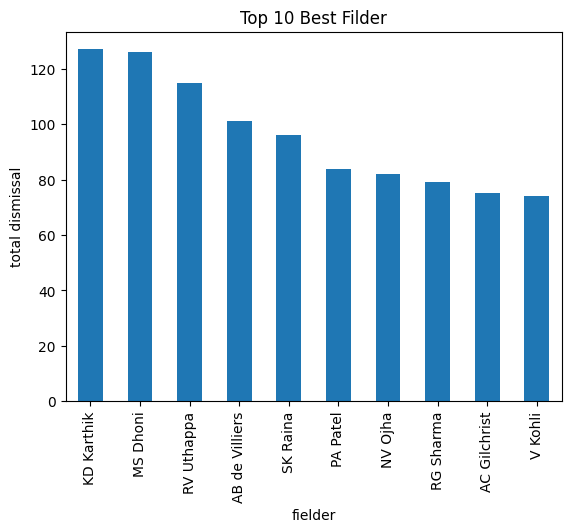

In [ ]:
deliveries.groupby('fielder')['fielder'].count().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Best Filder")
plt.xlabel("fielder")
plt.ylabel("total dismissal")
plt.show()

#toss decision

In [ ]:
matches.head(2)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN


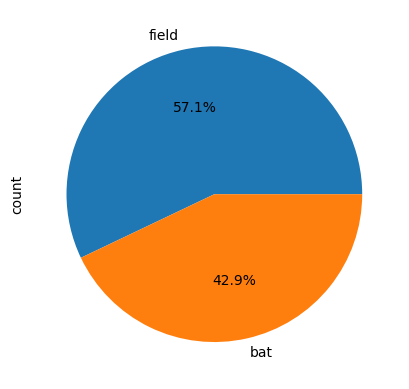

In [ ]:
from IPython.core.magics import auto
matches['toss_decision'].value_counts().plot(kind='pie',autopct='%0.1f%%')
plt.show()